In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 64
Z_DIM       = 128        # dimension du bruit latent
W_DIM       = 128        # dimension de l'espace W (mapping)
IMAGE_SIZE  = 64
CHANNELS    = 3
EPOCHS      = 30     
LR          = 1e-4
NUM_SAMPLES = 10          # images à générer à la fin

print(f"Device : {DEVICE}")

Device : cuda


-----------

# Dataset

100%|██████████| 170M/170M [00:01<00:00, 104MB/s]  


Nombre d'images d'entraînement : 50000
Nombre d'images de test : 10000
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


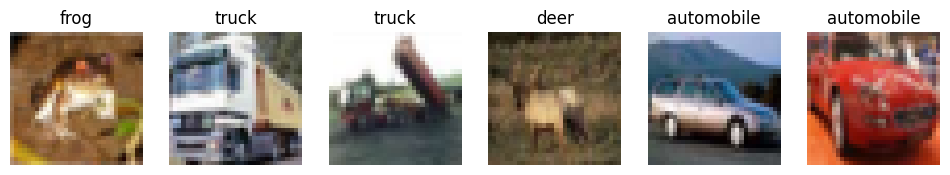

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Nombre d'images d'entraînement :", len(train_dataset))
print("Nombre d'images de test :", len(test_dataset))

classes = train_dataset.classes
print("Classes :", classes)

def show_images(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(12, 3))
    
    for i in range(n):
        img, label = dataset[i]
        
        # convertir tensor -> image
        img = img.numpy().transpose((1, 2, 0))
        
        axes[i].imshow(img)
        axes[i].set_title(classes[label])
        axes[i].axis('off')
    
    plt.show()

show_images(train_dataset)

# Pretraitement

In [3]:
# same first steps
transform = transforms.Compose([
    transforms.Resize((64, 64)),              # redimensionnement
    transforms.ToTensor(),                  
    transforms.Normalize([0.5]*3, [0.5]*3)    # normalisation [-1, 1]
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

image, label = train_dataset[0]
print("Shape de l'image :", image.shape)
print("Label :", label)

Shape de l'image : torch.Size([3, 64, 64])
Label : 6


# Option A – StyleGAN1

In [3]:
transform = transforms.Compose([ transforms.Resize(IMAGE_SIZE),   transforms.ToTensor(), transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)])
dataset = datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2, pin_memory=True)

print(f"Dataset chargé : {len(dataset)} images")

100%|██████████| 170M/170M [00:02<00:00, 64.5MB/s] 


Dataset chargé : 50000 images


- L’espace Z (bruit) est très entangled : changer un peu z change tout dans l’image.
- L’espace W est beaucoup plus disentangled : chaque dimension de w correspond plus clairement à une caractéristique

Prend un bruit aléatoire -> MLP 8 couches -> chaque couche : Linear → activationfunc -> W

AdaIN : l’injection de style 
- normalise les features x avec InstanceNorm
- transforme w en deux vecteurs : scale (multiplicateur) bias (décalage)
- scale * normalized + bias

- À chaque bloc de convolution, on prend le vecteur w (ou plusieurs w différents) et on le transforme en deux vecteurs :
    - A (style scale) → multiplicateur    ----      B (style bias) → décalage
- ==> on normalise les features de l’image, puis on les re-scale et re-décalage selon le style voulu.
    - Styles grossiers (coarse) : 4×4 à 8×8 → affectent la pose, la forme du visage, la structure globale.
    - Styles moyens (middle) : 16×16 à 32×32 → affectent les traits du visage, les yeux, le nez, etc.
    - Styles fins (fine) : 64×64 et plus → affectent les détails (texture de peau, cheveux, rides, etc.).

In [4]:
# Transformer le bruit aléatoire z en vecteur w
class MappingNetwork(nn.Module):  #Z → W
    def __init__(self, z_dim=Z_DIM, w_dim=W_DIM, depth=8):
        super().__init__()
        layers = []
        in_dim = z_dim
        for _ in range(depth):
            layers += [nn.Linear(in_dim, w_dim), nn.LeakyReLU(0.2)]
            in_dim = w_dim
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

# Injecter le style dans les features
class AdaIN(nn.Module):
    """Adaptive Instance Normalization"""
    def __init__(self, channels, w_dim=W_DIM):
        super().__init__()
        self.norm = nn.InstanceNorm2d(channels, affine=False)
        self.style_scale = nn.Linear(w_dim, channels)
        self.style_bias = nn.Linear(w_dim, channels)

    def forward(self, x, w):
        normalized = self.norm(x)
        scale = self.style_scale(w).unsqueeze(-1).unsqueeze(-1)
        bias = self.style_bias(w).unsqueeze(-1).unsqueeze(-1)
        return scale * normalized + bias


- Mapping = 8 couches linéaires, activation LeakyReLU -> un vecteur plus structuré = meilleur contrôle des images
- AdaIN = Injecter le style dans les features

- StyleGAN1Block :Upsample ×2 ->Convolution 3×3 → AdaIN → LeakyReLU-> Convolution 3×3 → AdaIN → LeakyReLU

In [5]:
class StyleGAN1Block(nn.Module):
    def __init__(self, in_ch, out_ch, w_dim=W_DIM, upsample=True):
        super().__init__()
        self.upsample = upsample
        self.conv1  = nn.Conv2d(in_ch,  out_ch, 3, 1, 1)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
        self.adain1 = AdaIN(out_ch, w_dim)
        self.adain2 = AdaIN(out_ch, w_dim)

    def forward(self, x, w):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2,
                              mode='bilinear', align_corners=False)
        x = F.leaky_relu(self.adain1(self.conv1(x), w), 0.2)
        x = F.leaky_relu(self.adain2(self.conv2(x), w), 0.2)
        return x
        # Conv -> AdaIN -> activation
# image devient plus grande plus détaillée


class GeneratorStyleGAN1(nn.Module):
    """4×4 → 8 → 16 → 32 → 64 pixels"""
    def __init__(self, z_dim=Z_DIM, w_dim=W_DIM):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const   = nn.Parameter(torch.randn(1, 512, 4, 4))
        self.blocks  = nn.ModuleList([
            StyleGAN1Block(512, 256),   # 4  → 8
            StyleGAN1Block(256, 128),   # 8  → 16
            StyleGAN1Block(128,  64),   # 16 → 32
            StyleGAN1Block( 64,  32),   # 32 → 64
        ])
        self.to_rgb = nn.Conv2d(32, 3, 1)

    def forward(self, z):
        w = self.mapping(z)
        x = self.const.expand(z.size(0), -1, -1, -1)
        for block in self.blocks:
            x = block(x, w)
        return torch.tanh(self.to_rgb(x)) # pixels entre -1 et 1



class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,   64,  4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64,  128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.LeakyReLU(0.2),
            nn.Conv2d(512,   1, 4, 1, 0),
        )

    def forward(self, x):
        return self.net(x).view(-1)

# distinguer vraie image fausse image
# CNN classique - réduction progressive de taille - sortie = score


In [8]:
def show_images(images, title="", nrow=5, save=True):
    images = (images + 1) / 2          # [-1,1] -> [0,1]
    grid   = vutils.make_grid(images[:nrow*2], nrow=nrow, padding=2)
    plt.figure(figsize=(12, 5))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    if save:
        plt.savefig(f"{title.replace(' ', '_')}.png", dpi=120,
                    bbox_inches='tight')
    plt.show()



Début entraînement StyleGAN1 …

Epoch [  1/30]  Loss_G=3.7841  Loss_D=0.4554
Epoch [  2/30]  Loss_G=2.5100  Loss_D=0.4516
Epoch [  3/30]  Loss_G=2.4152  Loss_D=0.4698
Epoch [  4/30]  Loss_G=2.5754  Loss_D=0.4382
Epoch [  5/30]  Loss_G=3.0168  Loss_D=0.3693
Epoch [  6/30]  Loss_G=3.5531  Loss_D=0.3102
Epoch [  7/30]  Loss_G=4.0749  Loss_D=0.2471
Epoch [  8/30]  Loss_G=4.4688  Loss_D=0.2300
Epoch [  9/30]  Loss_G=4.6321  Loss_D=0.2193
Epoch [ 10/30]  Loss_G=4.7999  Loss_D=0.2085


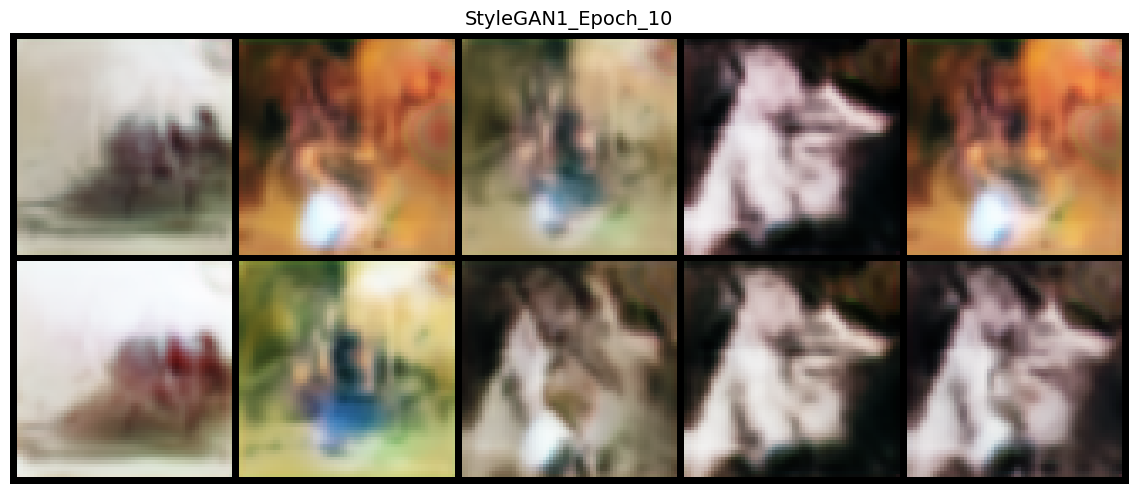

Epoch [ 11/30]  Loss_G=4.9603  Loss_D=0.2021
Epoch [ 12/30]  Loss_G=5.0398  Loss_D=0.1993
Epoch [ 13/30]  Loss_G=5.4776  Loss_D=0.1784
Epoch [ 14/30]  Loss_G=5.3682  Loss_D=0.1636
Epoch [ 15/30]  Loss_G=5.3872  Loss_D=0.1783
Epoch [ 16/30]  Loss_G=5.3404  Loss_D=0.1886
Epoch [ 17/30]  Loss_G=5.4292  Loss_D=0.1655
Epoch [ 18/30]  Loss_G=5.5858  Loss_D=0.1706
Epoch [ 19/30]  Loss_G=5.2463  Loss_D=0.1818
Epoch [ 20/30]  Loss_G=5.4439  Loss_D=0.1634


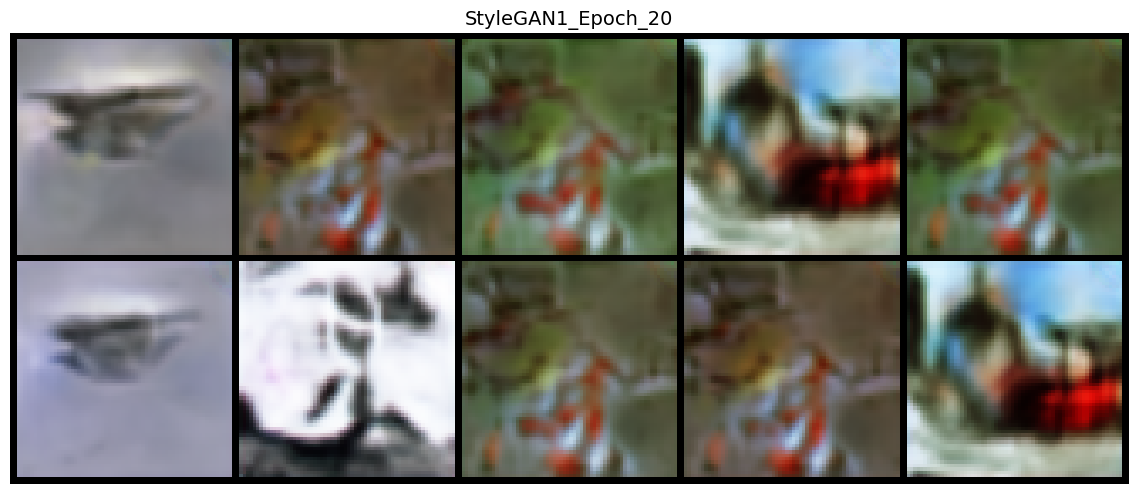

Epoch [ 21/30]  Loss_G=5.3258  Loss_D=0.1848
Epoch [ 22/30]  Loss_G=5.3953  Loss_D=0.1671
Epoch [ 23/30]  Loss_G=5.5709  Loss_D=0.1576
Epoch [ 24/30]  Loss_G=5.4217  Loss_D=0.1664
Epoch [ 25/30]  Loss_G=5.6889  Loss_D=0.1595
Epoch [ 26/30]  Loss_G=5.3265  Loss_D=0.1692
Epoch [ 27/30]  Loss_G=5.4110  Loss_D=0.1758
Epoch [ 28/30]  Loss_G=5.6038  Loss_D=0.1598
Epoch [ 29/30]  Loss_G=5.5817  Loss_D=0.1564
Epoch [ 30/30]  Loss_G=5.5592  Loss_D=0.1552


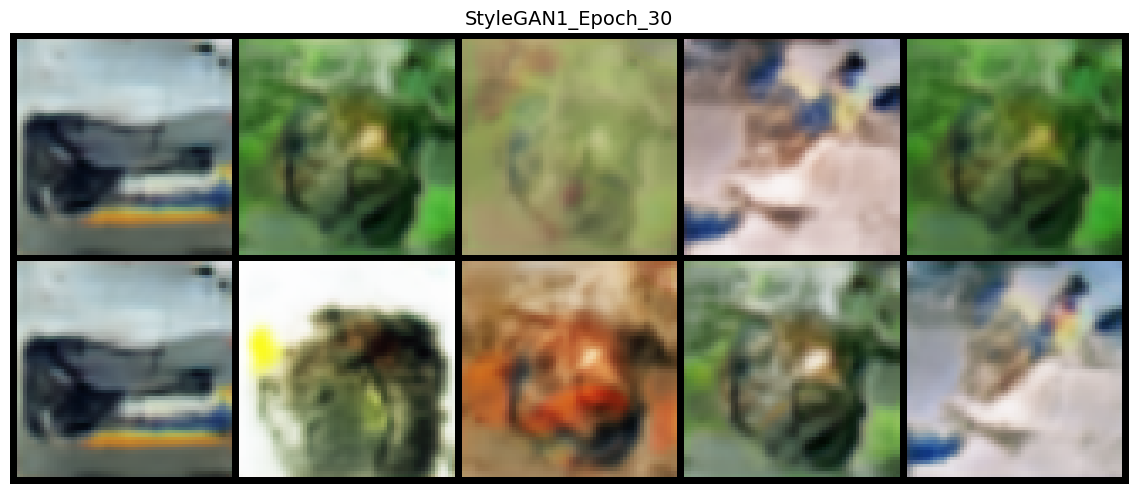

In [11]:
G = GeneratorStyleGAN1().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G     = optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.99))
opt_D     = optim.Adam(D.parameters(), lr=LR, betas=(0.0, 0.99))
criterion = nn.BCEWithLogitsLoss()

fixed_z   = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g_losses, d_losses = [], []

print("\nDébut entraînement StyleGAN1 …\n")

for epoch in range(1, EPOCHS + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z).detach()

        loss_D = (criterion(D(real), torch.ones(B, device=DEVICE)) +
                  criterion(D(fake), torch.zeros(B, device=DEVICE))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Generateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(B, device=DEVICE))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g_losses.append(g_sum / len(loader))
    d_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g_losses[-1]:.4f}  Loss_D={d_losses[-1]:.4f}")

    # Aperçu toutes les 10 époques
    if epoch % 10 == 0 or epoch == EPOCHS:
        with torch.no_grad():
            samples = G(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN1_Epoch_{epoch}")



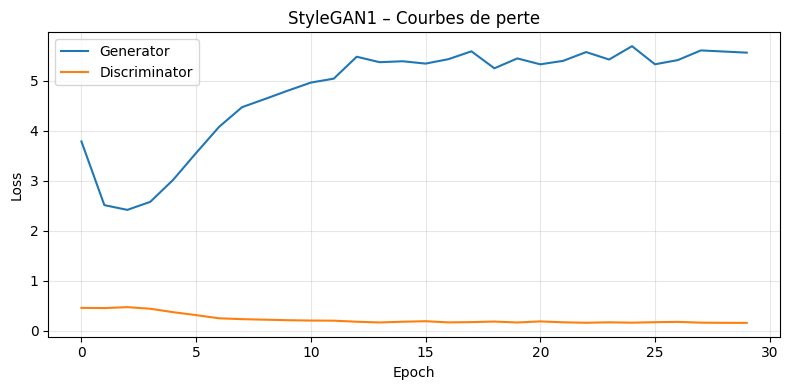

In [12]:
 # courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.title("StyleGAN1 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("StyleGAN1_loss.png", dpi=120)
plt.show()


Génération des 10 images finales …


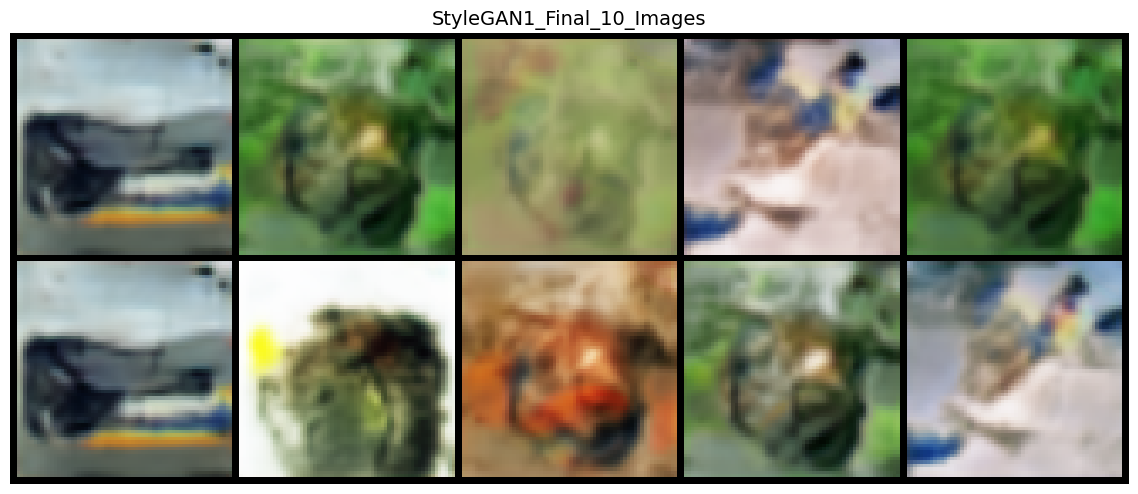

In [13]:
print("\nGénération des 10 images finales …")
with torch.no_grad():
    final_imgs = G(fixed_z).cpu()

show_images(final_imgs, title="StyleGAN1_Final_10_Images", nrow=5)


Début entraînement StyleGAN1 …

Epoch [  1/30]  Loss_G=3.9387  Loss_D=0.4474
Epoch [  2/30]  Loss_G=2.7964  Loss_D=0.3948
Epoch [  3/30]  Loss_G=2.6351  Loss_D=0.4283
Epoch [  4/30]  Loss_G=2.8405  Loss_D=0.3950
Epoch [  5/30]  Loss_G=3.5319  Loss_D=0.3173
Epoch [  6/30]  Loss_G=4.0156  Loss_D=0.2558
Epoch [  7/30]  Loss_G=4.3947  Loss_D=0.2193
Epoch [  8/30]  Loss_G=4.4558  Loss_D=0.2043
Epoch [  9/30]  Loss_G=4.6487  Loss_D=0.1889
Epoch [ 10/30]  Loss_G=4.6894  Loss_D=0.1893


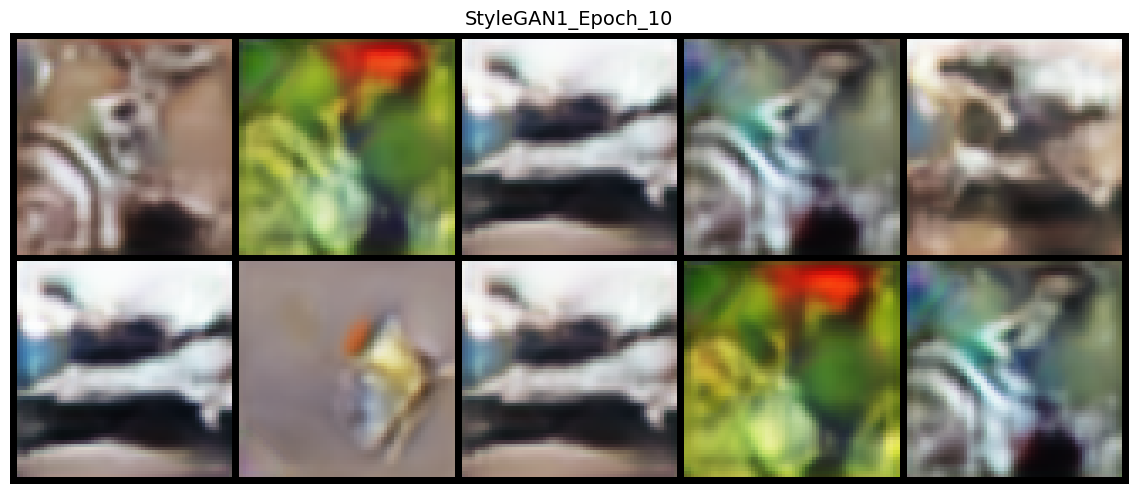

Epoch [ 11/30]  Loss_G=4.7970  Loss_D=0.1894
Epoch [ 12/30]  Loss_G=4.8400  Loss_D=0.1953
Epoch [ 13/30]  Loss_G=4.9362  Loss_D=0.1801
Epoch [ 14/30]  Loss_G=5.2369  Loss_D=0.1600
Epoch [ 15/30]  Loss_G=5.1925  Loss_D=0.1595
Epoch [ 16/30]  Loss_G=5.2439  Loss_D=0.1663
Epoch [ 17/30]  Loss_G=5.3352  Loss_D=0.1479
Epoch [ 18/30]  Loss_G=5.4236  Loss_D=0.1543
Epoch [ 19/30]  Loss_G=5.3616  Loss_D=0.1568
Epoch [ 20/30]  Loss_G=5.5032  Loss_D=0.1359


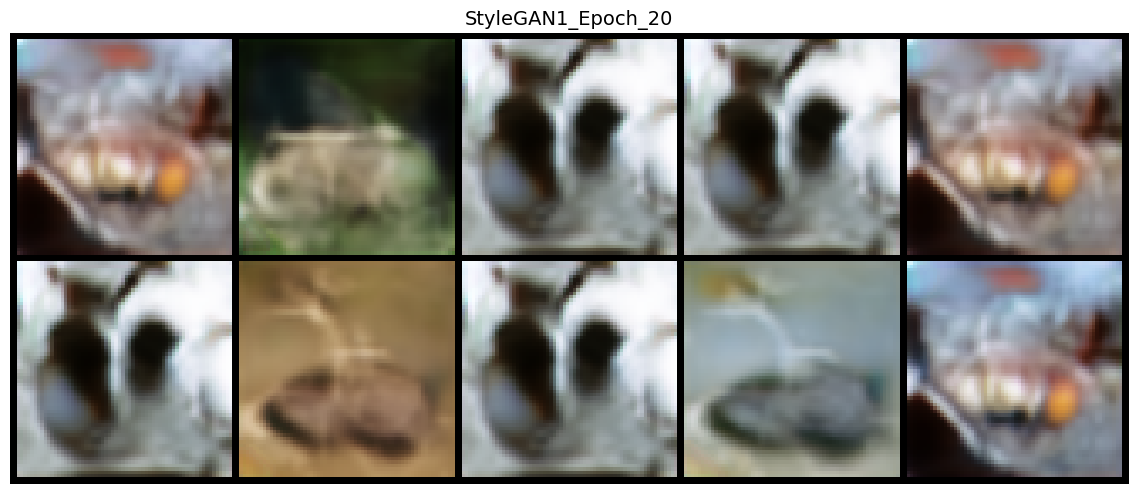

Epoch [ 21/30]  Loss_G=5.6788  Loss_D=0.1502
Epoch [ 22/30]  Loss_G=5.4005  Loss_D=0.1470
Epoch [ 23/30]  Loss_G=5.4551  Loss_D=0.1401
Epoch [ 24/30]  Loss_G=5.6868  Loss_D=0.1299
Epoch [ 25/30]  Loss_G=5.4506  Loss_D=0.1575
Epoch [ 26/30]  Loss_G=5.4319  Loss_D=0.1516
Epoch [ 27/30]  Loss_G=5.5306  Loss_D=0.1525
Epoch [ 28/30]  Loss_G=5.6334  Loss_D=0.1324
Epoch [ 29/30]  Loss_G=5.5802  Loss_D=0.1357
Epoch [ 30/30]  Loss_G=5.5927  Loss_D=0.1251


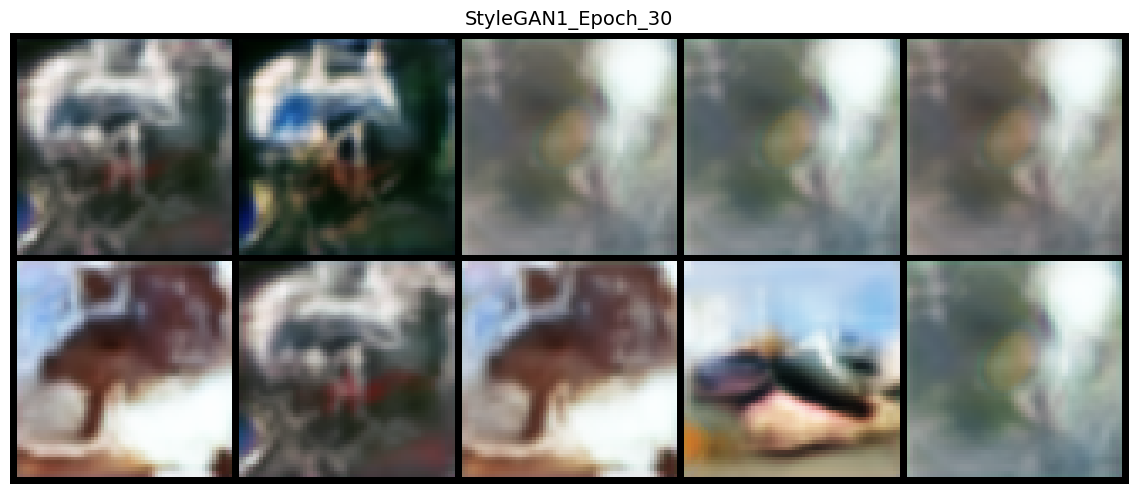

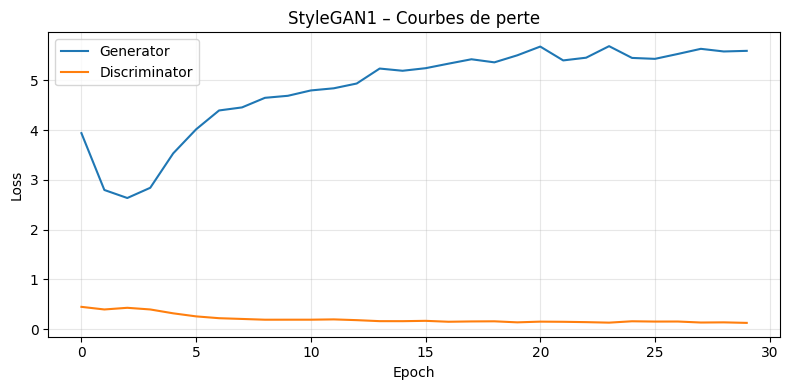


Génération des 10 images finales …


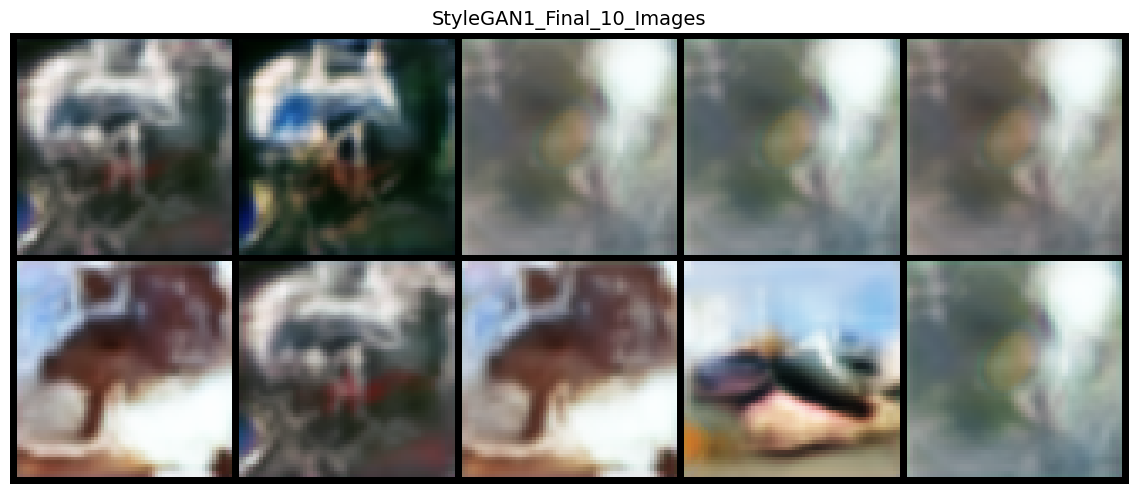

In [8]:
G = GeneratorStyleGAN1().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G     = optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.99))
opt_D     = optim.Adam(D.parameters(), lr=LR, betas=(0.0, 0.99))
criterion = nn.BCEWithLogitsLoss()

fixed_z   = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g_losses, d_losses = [], []

print("\nDébut entraînement StyleGAN1 …\n")

for epoch in range(1, EPOCHS + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z).detach()

        loss_D = (criterion(D(real), torch.ones(B, device=DEVICE)) +
                  criterion(D(fake), torch.zeros(B, device=DEVICE))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Générateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(B, device=DEVICE))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g_losses.append(g_sum / len(loader))
    d_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g_losses[-1]:.4f}  Loss_D={d_losses[-1]:.4f}")

    # Aperçu toutes les 10 époques
    if epoch % 10 == 0 or epoch == EPOCHS:
        with torch.no_grad():
            samples = G(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN1_Epoch_{epoch}")

 # courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.title("StyleGAN1 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("StyleGAN1_loss.png", dpi=120)
plt.show()

print("\nGénération des 10 images finales …")
with torch.no_grad():
    final_imgs = G(fixed_z).cpu()

show_images(final_imgs, title="StyleGAN1_Final_10_Images", nrow=5)

____________

LAST 11 04 2026


Début entraînement StyleGAN1 …

Epoch [  1/30]  Loss_G=2.2826  Loss_D=0.5916
Epoch [  2/30]  Loss_G=1.1716  Loss_D=0.6684
Epoch [  3/30]  Loss_G=1.1453  Loss_D=0.6516
Epoch [  4/30]  Loss_G=1.2008  Loss_D=0.6293
Epoch [  5/30]  Loss_G=1.3676  Loss_D=0.5727
Epoch [  6/30]  Loss_G=1.5480  Loss_D=0.5243
Epoch [  7/30]  Loss_G=1.7767  Loss_D=0.4682
Epoch [  8/30]  Loss_G=1.9968  Loss_D=0.4377
Epoch [  9/30]  Loss_G=2.1470  Loss_D=0.4087
Epoch [ 10/30]  Loss_G=2.3131  Loss_D=0.3826


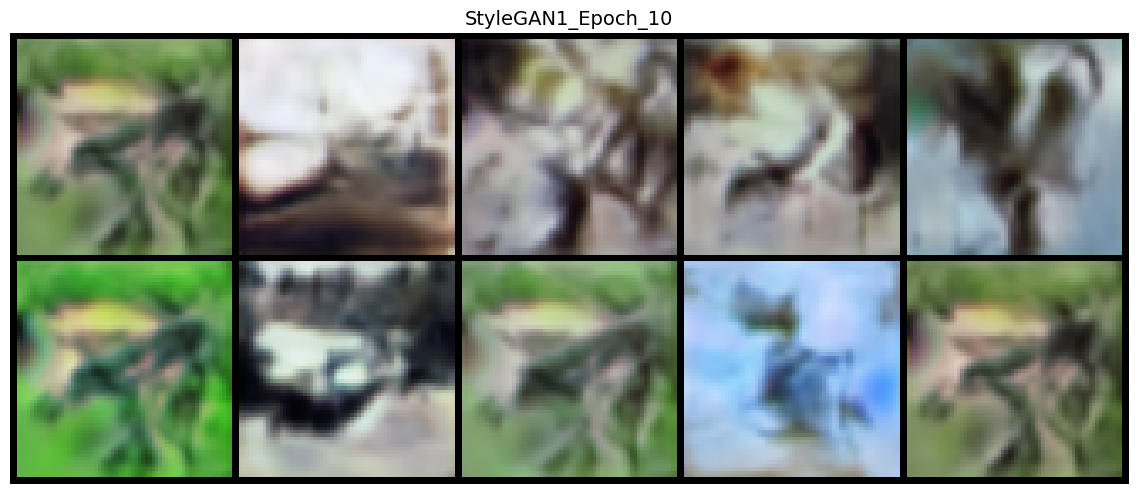

Epoch [ 11/30]  Loss_G=2.5147  Loss_D=0.3558
Epoch [ 12/30]  Loss_G=2.7228  Loss_D=0.3333
Epoch [ 13/30]  Loss_G=2.8147  Loss_D=0.3121
Epoch [ 14/30]  Loss_G=3.0815  Loss_D=0.2869
Epoch [ 15/30]  Loss_G=3.1507  Loss_D=0.2977
Epoch [ 16/30]  Loss_G=3.1971  Loss_D=0.2812
Epoch [ 17/30]  Loss_G=3.3013  Loss_D=0.2764
Epoch [ 18/30]  Loss_G=3.4090  Loss_D=0.2525
Epoch [ 19/30]  Loss_G=3.5293  Loss_D=0.2665
Epoch [ 20/30]  Loss_G=3.6603  Loss_D=0.2410


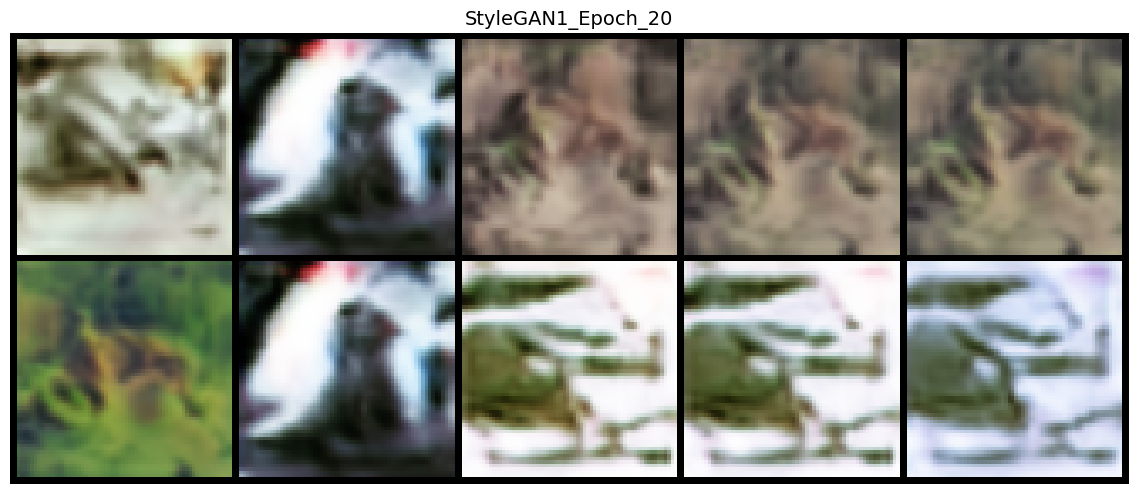

Epoch [ 21/30]  Loss_G=3.6450  Loss_D=0.2400
Epoch [ 22/30]  Loss_G=3.8090  Loss_D=0.2310
Epoch [ 23/30]  Loss_G=3.8618  Loss_D=0.2145
Epoch [ 24/30]  Loss_G=3.8095  Loss_D=0.2382
Epoch [ 25/30]  Loss_G=4.1087  Loss_D=0.1936
Epoch [ 26/30]  Loss_G=4.4426  Loss_D=0.1768
Epoch [ 27/30]  Loss_G=4.1946  Loss_D=0.2006
Epoch [ 28/30]  Loss_G=4.2396  Loss_D=0.1982
Epoch [ 29/30]  Loss_G=4.3463  Loss_D=0.1925
Epoch [ 30/30]  Loss_G=4.2255  Loss_D=0.1863


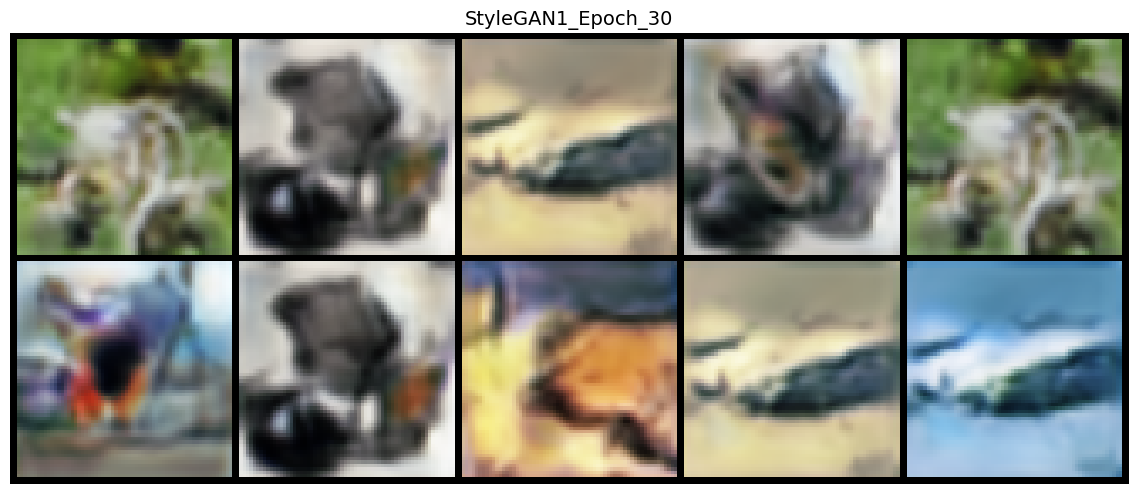

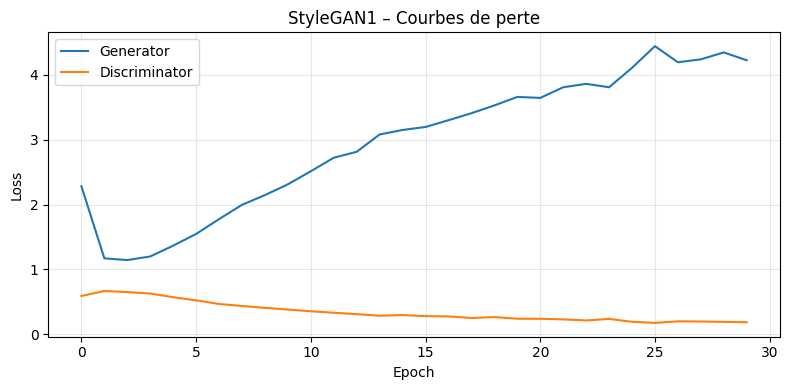

In [9]:
G = GeneratorStyleGAN1().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(),  lr=2e-4, betas=(0.0, 0.99))
opt_D = optim.Adam(D.parameters(),  lr=5e-5, betas=(0.0, 0.99)) 
criterion = nn.BCEWithLogitsLoss()

fixed_z   = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g_losses, d_losses = [], []

print("\nDébut entraînement StyleGAN1 …\n")

for epoch in range(1, EPOCHS + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z).detach()

        loss_D = (criterion(D(real), torch.ones(B, device=DEVICE)) +
                  criterion(D(fake), torch.zeros(B, device=DEVICE))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Generateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(B, device=DEVICE))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g_losses.append(g_sum / len(loader))
    d_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g_losses[-1]:.4f}  Loss_D={d_losses[-1]:.4f}")

    # Aperçu toutes les 10 époques
    if epoch % 10 == 0 or epoch == EPOCHS:
        with torch.no_grad():
            samples = G(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN1_Epoch_{epoch}")

 # courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.title("StyleGAN1 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("StyleGAN1_loss.png", dpi=120)
plt.show()


Génération des 10 images finales …


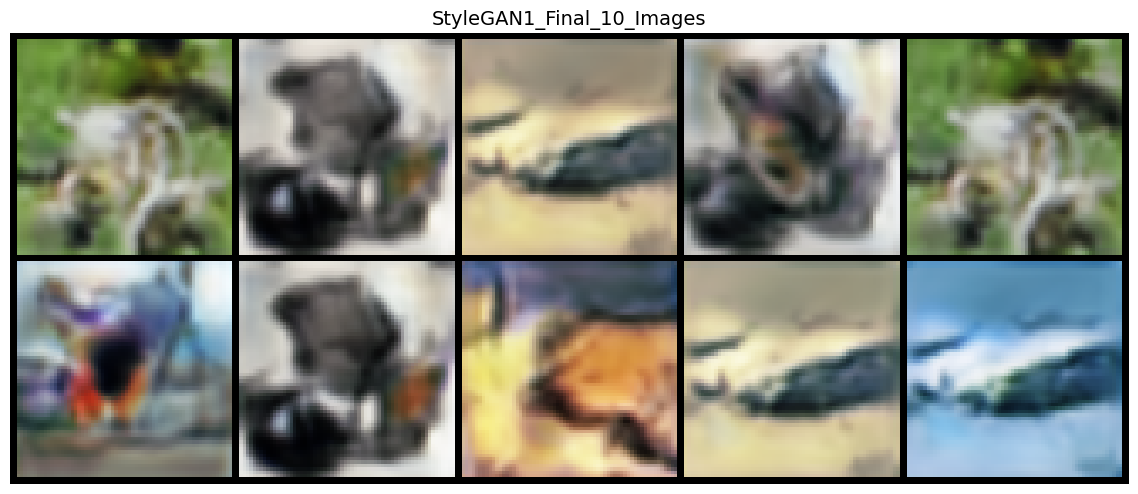

In [10]:
print("\nGénération des 10 images finales …")
with torch.no_grad():
    final_imgs = G(fixed_z).cpu()

show_images(final_imgs, title="StyleGAN1_Final_10_Images", nrow=5)


Début entraînement StyleGAN1 …

Epoch [  1/30]  Loss_G=2.0221  Loss_D=0.6401
Epoch [  2/30]  Loss_G=1.0423  Loss_D=0.6882
Epoch [  3/30]  Loss_G=1.1999  Loss_D=0.6390
Epoch [  4/30]  Loss_G=1.2495  Loss_D=0.6173
Epoch [  5/30]  Loss_G=1.3834  Loss_D=0.5781
Epoch [  6/30]  Loss_G=1.5779  Loss_D=0.5271
Epoch [  7/30]  Loss_G=1.8299  Loss_D=0.4722
Epoch [  8/30]  Loss_G=2.0658  Loss_D=0.4301
Epoch [  9/30]  Loss_G=2.2902  Loss_D=0.3932
Epoch [ 10/30]  Loss_G=2.5206  Loss_D=0.3618


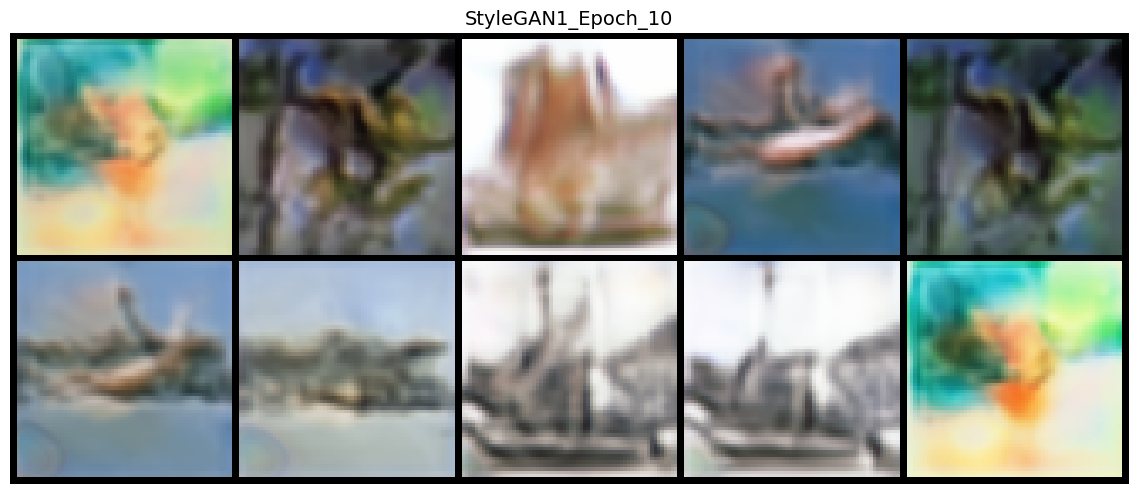

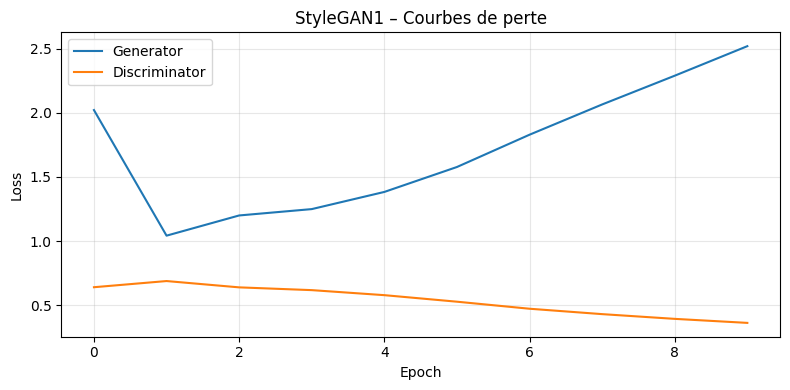


Génération des 10 images finales …


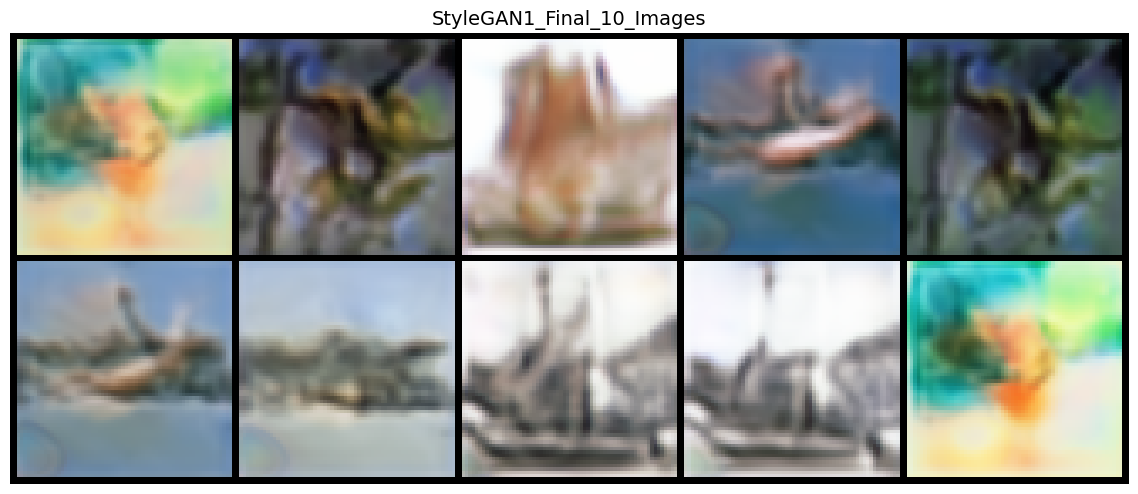

In [15]:
G = GeneratorStyleGAN1().to(DEVICE)
D = Discriminator().to(DEVICE)

opt_G = optim.Adam(G.parameters(),  lr=2e-4, betas=(0.0, 0.99))
opt_D = optim.Adam(D.parameters(),  lr=5e-5, betas=(0.0, 0.99)) 
criterion = nn.BCEWithLogitsLoss()

fixed_z   = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g_losses, d_losses = [], []

print("\nDébut entraînement StyleGAN1 …\n")

for epoch in range(1, 10 + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z).detach()

        loss_D = (criterion(D(real), torch.ones(B, device=DEVICE)) +
                  criterion(D(fake), torch.zeros(B, device=DEVICE))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Generateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G(z)
        loss_G = criterion(D(fake), torch.ones(B, device=DEVICE))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g_losses.append(g_sum / len(loader))
    d_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g_losses[-1]:.4f}  Loss_D={d_losses[-1]:.4f}")

    # Aperçu toutes les 10 époques
    if epoch % 10 == 0 or epoch == 10:
        with torch.no_grad():
            samples = G(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN1_Epoch_{epoch}")

 # courbe de perte
plt.figure(figsize=(8, 4))
plt.plot(g_losses, label="Generator")
plt.plot(d_losses, label="Discriminator")
plt.title("StyleGAN1 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("\nGénération des 10 images finales …")
with torch.no_grad():
    final_imgs = G(fixed_z).cpu()

show_images(final_imgs, title="StyleGAN1_Final_10_Images", nrow=5)

___________

- Loss G ↓ → meilleur générateur
- Loss D stable → bon équilibre

_______________________

_______________________

# Option B – StyleGAN2

------

- Remplace AdaIN par Modulation + Demodulation (Mod/Demod) : plus stable et évite les artefacts.
- Normalisation des poids du générateur.
- Suppression du bruit dans certaines couches.
- Meilleure régularisation.

In [6]:
class ModulatedConv2d(nn.Module):
    """
    Remplace AdaIN par :
      1. Modulation des poids via le vecteur style w
      2. Démodulation = normalisation des poids
    """
    def __init__(self, in_ch, out_ch, kernel=3, w_dim=W_DIM):
        super().__init__()
        self.out_ch     = out_ch
        self.in_ch      = in_ch
        self.kernel     = kernel
        self.padding    = kernel // 2
        self.weight     = nn.Parameter(
            torch.randn(out_ch, in_ch, kernel, kernel))
        self.modulation = nn.Linear(w_dim, in_ch)

    def forward(self, x, w):
        B, C, H, W_img = x.shape

        # mod
        style  = self.modulation(w).view(B, 1, C, 1, 1) + 1
        weight = self.weight.unsqueeze(0) * style        # (B, out, in, k, k)

        # demod
        denom  = weight.pow(2).sum([2, 3, 4], keepdim=True).sqrt() + 1e-8
        weight = weight / denom

        # conv groupé
        weight = weight.view(B * self.out_ch, C, self.kernel, self.kernel)
        x      = x.view(1, B * C, H, W_img)
        x      = F.conv2d(x, weight, padding=self.padding, groups=B)
        return x.view(B, self.out_ch, H, W_img)
        

- 1- ela permet au style w de modifier les poids de la convolution elle-même
- 2- Dans StyleGAN1, AdaIN pouvait créer des artefacts en forme de "blobs" ou "gouttes d’eau" parce que les statistiques des features variaient trop fortement. La démodulation supprime presque complètement ces artefacts.
- remplace Conv2d + AdaIN de StyleGAN1

In [6]:
class StyleGAN2Block(nn.Module):
    """
    Améliorations vs StyleGAN1 :
      - ModulatedConv2d à la place de Conv + AdaIN
      - Bruit stochastique injecté APRÈS chaque convolution
    """
    def __init__(self, in_ch, out_ch, w_dim=W_DIM, upsample=True):
        super().__init__()
        self.upsample      = upsample
        self.conv1         = ModulatedConv2d(in_ch,  out_ch, w_dim=w_dim)
        self.conv2         = ModulatedConv2d(out_ch, out_ch, w_dim=w_dim)
        # Poids appris pour le bruit injecté
        self.noise_weight1 = nn.Parameter(torch.zeros(1))
        self.noise_weight2 = nn.Parameter(torch.zeros(1))

    def forward(self, x, w):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2,
                              mode='bilinear', align_corners=False)

        # Couche 1 + bruit
        B, C, H, W_img = x.shape
        noise1 = torch.randn(B, 1, H, W_img, device=x.device) * 0.1 # *0.1 rend le bruit moins fort
        x = F.leaky_relu(self.conv1(x, w) + self.noise_weight1 * noise1, 0.2)

        # Couche 2 + bruit
        noise2 = torch.randn(B, 1, x.size(2), x.size(3), device=x.device)* 0.1
        x = F.leaky_relu(self.conv2(x, w) + self.noise_weight2 * noise2, 0.2)
        return x


class GeneratorStyleGAN2(nn.Module):
    """4×4 → 8 → 16 → 32 → 64 pixels avec weight demodulation"""
    def __init__(self, z_dim=Z_DIM, w_dim=W_DIM):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const   = nn.Parameter(torch.randn(1, 512, 4, 4))
        self.blocks  = nn.ModuleList([
            StyleGAN2Block(512, 256),   # 4  → 8
            StyleGAN2Block(256, 128),   # 8  → 16
            StyleGAN2Block(128,  64),   # 16 → 32
            StyleGAN2Block( 64,  32),   # 32 → 64
        ])
        self.to_rgb = nn.Conv2d(32, 3, 1)

    def forward(self, z):
        w = self.mapping(z)
        x = self.const.expand(z.size(0), -1, -1, -1)
        for block in self.blocks:
            x = block(x, w)
        return torch.tanh(self.to_rgb(x))

- AdaIN → remplacé par ModulatedConv2d
- Injection de bruit après chaque convolution

"L’initialisation des poids est particulièrement importante dans StyleGAN2 en raison de la présence de la modulation et de la démolition des poids. Ces mécanismes rendent le modèle plus sensible aux valeurs initiales, ce qui peut affecter la stabilité de l’entraînement. En revanche, StyleGAN1 est moins sensible grâce à l’utilisation de AdaIN, qui normalise les activations."

"On initialise les poids surtout dans StyleGAN2 car il est plus sensible aux valeurs initiales à cause de la modulation et de la démodulation, contrairement à StyleGAN1 qui est plus stable grâce à AdaIN."

initilalisationde poids ici plus critique car 
- StyleGAN2 est plus complexe. Il contient :ModulatedCon - Demodulation - Bruit injecté
Donc :plus de calculs, plus de risques d’instabilité
- Modulation dépend directement des poids


Début entraînement StyleGAN2 …

Epoch [  1/30]  Loss_G=8.5099  Loss_D=0.0866
Epoch [  2/30]  Loss_G=8.0250  Loss_D=0.1054
Epoch [  3/30]  Loss_G=6.7213  Loss_D=0.1593
Epoch [  4/30]  Loss_G=6.6633  Loss_D=0.1091
Epoch [  5/30]  Loss_G=6.9519  Loss_D=0.0958
Epoch [  6/30]  Loss_G=7.3488  Loss_D=0.0849
Epoch [  7/30]  Loss_G=7.5522  Loss_D=0.0680
Epoch [  8/30]  Loss_G=7.3850  Loss_D=0.0561
Epoch [  9/30]  Loss_G=7.5499  Loss_D=0.0566
Epoch [ 10/30]  Loss_G=7.5162  Loss_D=0.0472


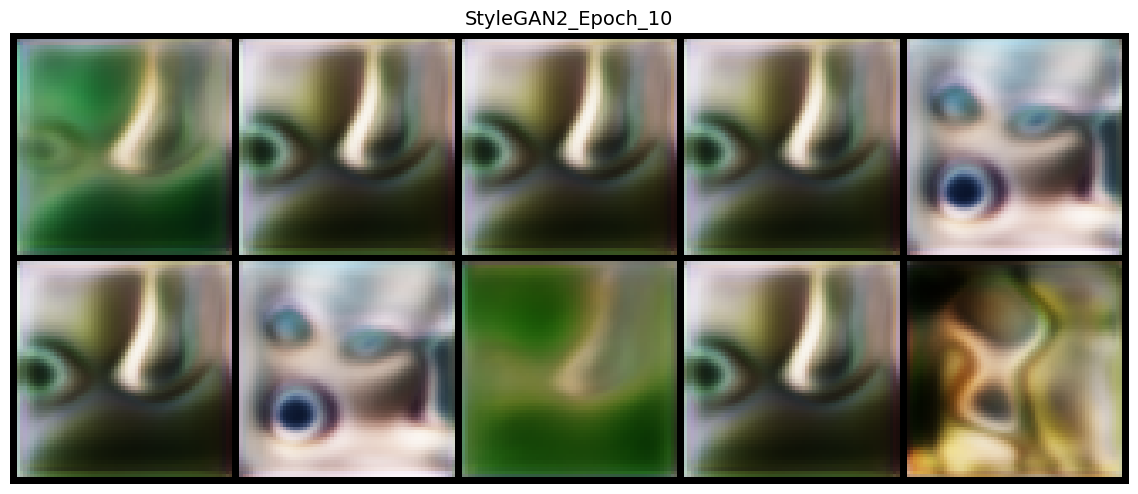

Epoch [ 11/30]  Loss_G=8.1878  Loss_D=0.0375
Epoch [ 12/30]  Loss_G=7.8136  Loss_D=0.0373
Epoch [ 13/30]  Loss_G=8.1761  Loss_D=0.0483
Epoch [ 14/30]  Loss_G=8.3334  Loss_D=0.0376
Epoch [ 15/30]  Loss_G=8.2348  Loss_D=0.0413
Epoch [ 16/30]  Loss_G=7.2574  Loss_D=0.0535
Epoch [ 17/30]  Loss_G=7.1847  Loss_D=0.0799
Epoch [ 18/30]  Loss_G=7.0842  Loss_D=0.0585
Epoch [ 19/30]  Loss_G=6.5171  Loss_D=0.0750
Epoch [ 20/30]  Loss_G=6.8648  Loss_D=0.0542


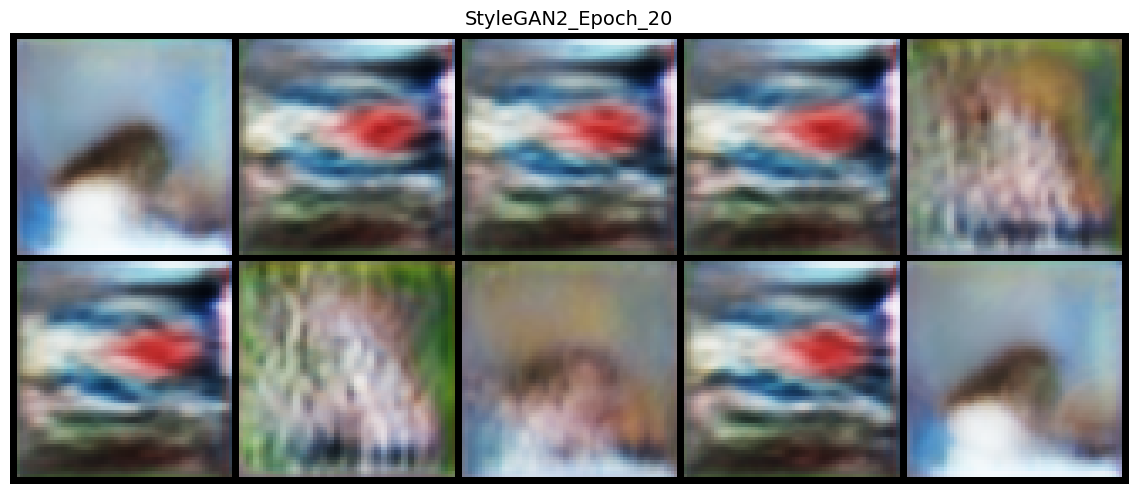

Epoch [ 21/30]  Loss_G=7.1804  Loss_D=0.0654
Epoch [ 22/30]  Loss_G=6.8456  Loss_D=0.0421
Epoch [ 23/30]  Loss_G=7.6154  Loss_D=0.0481
Epoch [ 24/30]  Loss_G=7.1659  Loss_D=0.0516
Epoch [ 25/30]  Loss_G=7.6656  Loss_D=0.0242
Epoch [ 26/30]  Loss_G=7.1336  Loss_D=0.0550
Epoch [ 27/30]  Loss_G=7.3640  Loss_D=0.0441
Epoch [ 28/30]  Loss_G=10.1251  Loss_D=0.0171
Epoch [ 29/30]  Loss_G=8.5103  Loss_D=0.0086
Epoch [ 30/30]  Loss_G=7.4264  Loss_D=0.0550


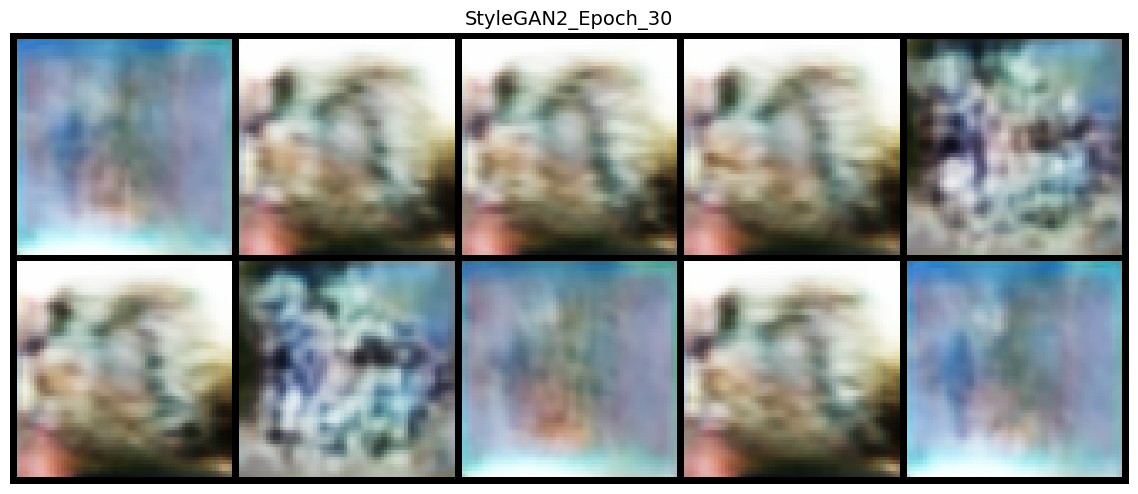

In [18]:
G2 = GeneratorStyleGAN2().to(DEVICE)
D2 = Discriminator().to(DEVICE)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
#initialisation des poids
G2.apply(init_weights)
D2.apply(init_weights)



opt_G     = optim.Adam(G2.parameters(), lr=LR, betas=(0.0, 0.99))
opt_D     = optim.Adam(D2.parameters(), lr=LR, betas=(0.0, 0.99))
criterion = nn.BCEWithLogitsLoss()

fixed_z    = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g2_losses, d2_losses = [], []

print("\nDébut entraînement StyleGAN2 …\n")

for epoch in range(1, EPOCHS + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z).detach()

        loss_D = (criterion(D2(real), torch.ones_like(D2(real)))+
                  criterion(D2(fake), torch.zeros_like(D2(fake)))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Générateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z)
        loss_G = criterion(D2(fake), torch.ones_like(D2(fake)))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g2_losses.append(g_sum / len(loader))
    d2_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g2_losses[-1]:.4f}  Loss_D={d2_losses[-1]:.4f}")

    if epoch % 10 == 0 or epoch == EPOCHS:
        with torch.no_grad():
            samples = G2(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN2_Epoch_{epoch}")




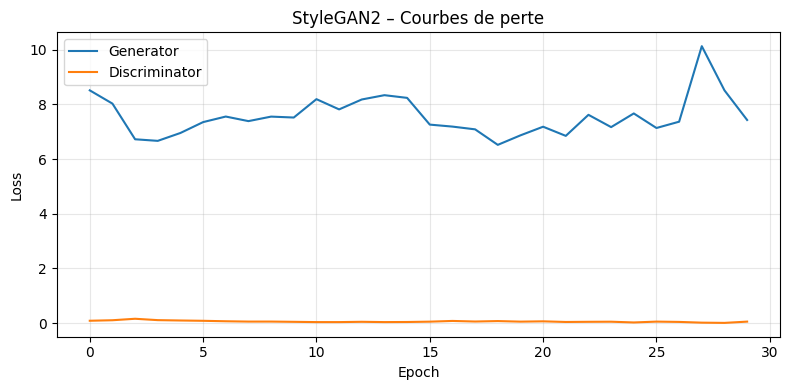

In [19]:

plt.figure(figsize=(8, 4))
plt.plot(g2_losses, label="Generator")
plt.plot(d2_losses, label="Discriminator")
plt.title("StyleGAN2 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("StyleGAN2_loss.png", dpi=120)
plt.show()

**====> COLLAPS**

reduire lr de D + ajout de bruit


Début entraînement StyleGAN2 …

Epoch [  1/30]  Loss_G=3.4262  Loss_D=0.1364
Epoch [  2/30]  Loss_G=3.1710  Loss_D=0.1422
Epoch [  3/30]  Loss_G=3.1152  Loss_D=0.1379
Epoch [  4/30]  Loss_G=2.4267  Loss_D=0.2814
Epoch [  5/30]  Loss_G=2.3442  Loss_D=0.2542
Epoch [  6/30]  Loss_G=2.4703  Loss_D=0.2595
Epoch [  7/30]  Loss_G=2.6802  Loss_D=0.2274
Epoch [  8/30]  Loss_G=2.3562  Loss_D=0.2836
Epoch [  9/30]  Loss_G=2.5172  Loss_D=0.2294
Epoch [ 10/30]  Loss_G=2.3848  Loss_D=0.2709


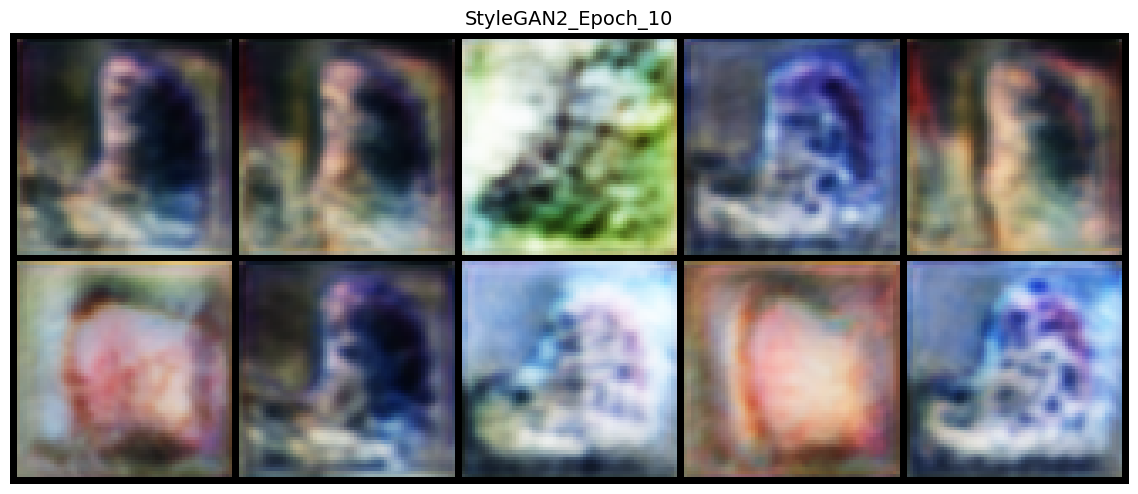

Epoch [ 11/30]  Loss_G=2.4425  Loss_D=0.2760
Epoch [ 12/30]  Loss_G=2.4050  Loss_D=0.2753
Epoch [ 13/30]  Loss_G=2.4649  Loss_D=0.2560
Epoch [ 14/30]  Loss_G=2.5461  Loss_D=0.2552
Epoch [ 15/30]  Loss_G=2.5156  Loss_D=0.2601
Epoch [ 16/30]  Loss_G=2.3748  Loss_D=0.2830
Epoch [ 17/30]  Loss_G=2.2981  Loss_D=0.3105
Epoch [ 18/30]  Loss_G=2.4357  Loss_D=0.2777
Epoch [ 19/30]  Loss_G=2.4933  Loss_D=0.2775
Epoch [ 20/30]  Loss_G=2.5245  Loss_D=0.2690


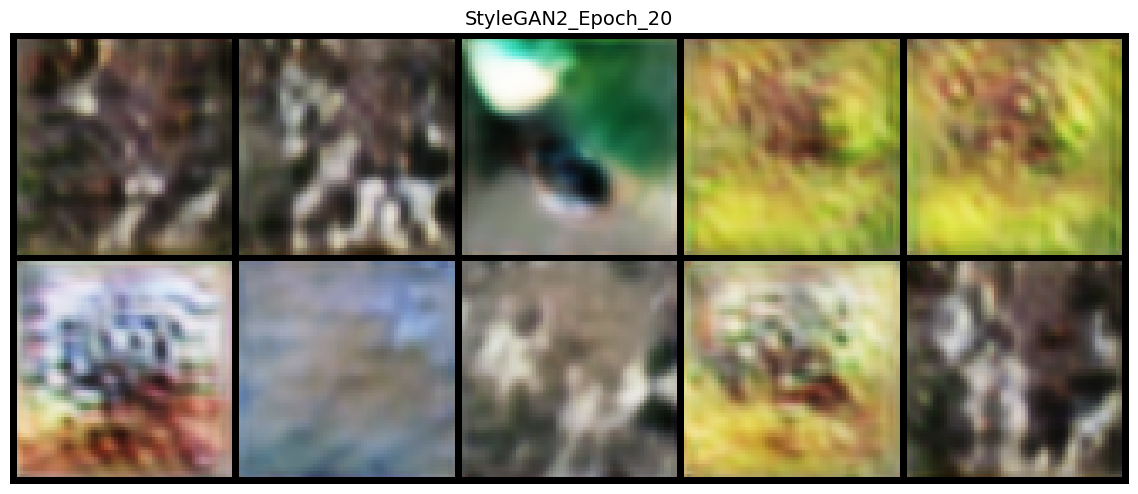

Epoch [ 21/30]  Loss_G=2.5293  Loss_D=0.2628
Epoch [ 22/30]  Loss_G=2.5992  Loss_D=0.2520
Epoch [ 23/30]  Loss_G=2.6465  Loss_D=0.2497
Epoch [ 24/30]  Loss_G=2.7863  Loss_D=0.2196
Epoch [ 25/30]  Loss_G=2.8678  Loss_D=0.2091
Epoch [ 26/30]  Loss_G=2.9729  Loss_D=0.1958
Epoch [ 27/30]  Loss_G=3.1790  Loss_D=0.1653
Epoch [ 28/30]  Loss_G=3.0083  Loss_D=0.2069
Epoch [ 29/30]  Loss_G=2.8664  Loss_D=0.2237
Epoch [ 30/30]  Loss_G=2.9521  Loss_D=0.2044


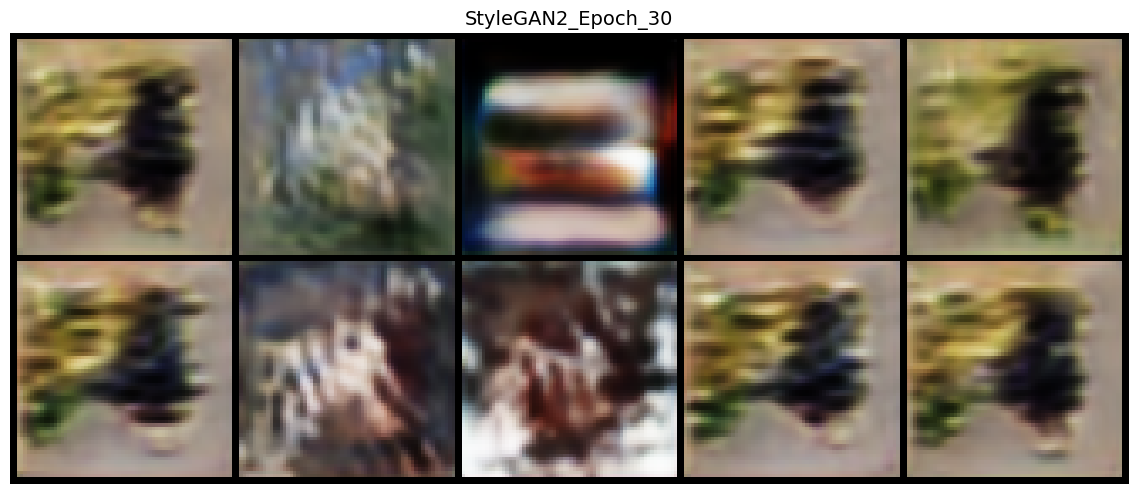

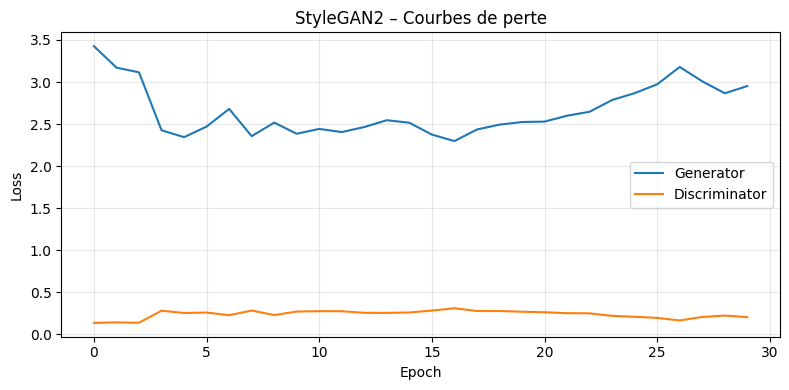

In [21]:
class StyleGAN2Block(nn.Module):
    """
    Améliorations vs StyleGAN1 :
      - ModulatedConv2d à la place de Conv + AdaIN
      - Bruit stochastique injecté APRÈS chaque convolution
    """
    def __init__(self, in_ch, out_ch, w_dim=W_DIM, upsample=True):
        super().__init__()
        self.upsample      = upsample
        self.conv1         = ModulatedConv2d(in_ch,  out_ch, w_dim=w_dim)
        self.conv2         = ModulatedConv2d(out_ch, out_ch, w_dim=w_dim)
        # Poids appris pour le bruit injecté
        self.noise_weight1 = nn.Parameter(torch.zeros(1))
        self.noise_weight2 = nn.Parameter(torch.zeros(1))

    def forward(self, x, w):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2,
                              mode='bilinear', align_corners=False)

        # Couche 1 + bruit
        B, C, H, W_img = x.shape
        noise1 = torch.randn(B, 1, H, W_img, device=x.device) #* 0.1 # *0.1 rend le bruit moins fort
        x = F.leaky_relu(self.conv1(x, w) + self.noise_weight1 * noise1, 0.2)

        # Couche 2 + bruit
        noise2 = torch.randn(B, 1, x.size(2), x.size(3), device=x.device)#* 0.1
        x = F.leaky_relu(self.conv2(x, w) + self.noise_weight2 * noise2, 0.2)
        return x


class GeneratorStyleGAN2(nn.Module):
    """4×4 → 8 → 16 → 32 → 64 pixels avec weight demodulation"""
    def __init__(self, z_dim=Z_DIM, w_dim=W_DIM):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const   = nn.Parameter(torch.randn(1, 512, 4, 4))
        self.blocks  = nn.ModuleList([
            StyleGAN2Block(512, 256),   # 4  → 8
            StyleGAN2Block(256, 128),   # 8  → 16
            StyleGAN2Block(128,  64),   # 16 → 32
            StyleGAN2Block( 64,  32),   # 32 → 64
        ])
        self.to_rgb = nn.Conv2d(32, 3, 1)

    def forward(self, z):
        w = self.mapping(z)
        x = self.const.expand(z.size(0), -1, -1, -1)
        for block in self.blocks:
            x = block(x, w)
        return torch.tanh(self.to_rgb(x))

#-----------------------

G2 = GeneratorStyleGAN2().to(DEVICE)
D2 = Discriminator().to(DEVICE)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
#initialisation des poids
G2.apply(init_weights)
D2.apply(init_weights)


LR_G = 1e-4    
LR_D = 1e-5 
opt_G = optim.Adam(G2.parameters(), lr=LR_G, betas=(0.0, 0.99))
opt_D = optim.Adam(D2.parameters(), lr=LR_D, betas=(0.0, 0.99))
criterion = nn.BCEWithLogitsLoss()

fixed_z    = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g2_losses, d2_losses = [], []

print("\nDébut entraînement StyleGAN2 …\n")

for epoch in range(1, EPOCHS + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z).detach()

        loss_D = (criterion(D2(real), torch.ones_like(D2(real)))+
                  criterion(D2(fake), torch.zeros_like(D2(fake)))) / 2

        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # — Générateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z)
        loss_G = criterion(D2(fake), torch.ones_like(D2(fake)))

        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g2_losses.append(g_sum / len(loader))
    d2_losses.append(d_sum / len(loader))

    print(f"Epoch [{epoch:3d}/{EPOCHS}]  "
          f"Loss_G={g2_losses[-1]:.4f}  Loss_D={d2_losses[-1]:.4f}")

    if epoch % 10 == 0 or epoch == EPOCHS:
        with torch.no_grad():
            samples = G2(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN2_Epoch_{epoch}")



plt.figure(figsize=(8, 4))
plt.plot(g2_losses, label="Generator")
plt.plot(d2_losses, label="Discriminator")
plt.title("StyleGAN2 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("StyleGAN2_loss2.png", dpi=120)
plt.show()

In [ ]:
class StyleGAN2Block(nn.Module):
    """
    Améliorations vs StyleGAN1 :
      - ModulatedConv2d à la place de Conv + AdaIN
      - Bruit stochastique injecté APRÈS chaque convolution
    """
    def __init__(self, in_ch, out_ch, w_dim=W_DIM, upsample=True):
        super().__init__()
        self.upsample      = upsample
        self.conv1         = ModulatedConv2d(in_ch,  out_ch, w_dim=w_dim)
        self.conv2         = ModulatedConv2d(out_ch, out_ch, w_dim=w_dim)
        # Poids appris pour le bruit injecté
        self.noise_weight1 = nn.Parameter(torch.zeros(1))
        self.noise_weight2 = nn.Parameter(torch.zeros(1))

    def forward(self, x, w):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2,
                              mode='bilinear', align_corners=False)

        # Couche 1 + bruit
        B, C, H, W_img = x.shape
        noise1 = torch.randn(B, 1, H, W_img, device=x.device) #* 0.1 # *0.1 rend le bruit moins fort
        x = F.leaky_relu(self.conv1(x, w) + self.noise_weight1 * noise1, 0.2)

        # Couche 2 + bruit
        noise2 = torch.randn(B, 1, x.size(2), x.size(3), device=x.device)#* 0.1
        x = F.leaky_relu(self.conv2(x, w) + self.noise_weight2 * noise2, 0.2)
        return x


class GeneratorStyleGAN2(nn.Module):
    """4×4 → 8 → 16 → 32 → 64 pixels avec weight demodulation"""
    def __init__(self, z_dim=Z_DIM, w_dim=W_DIM):
        super().__init__()
        self.mapping = MappingNetwork(z_dim, w_dim)
        self.const   = nn.Parameter(torch.randn(1, 512, 4, 4))
        self.blocks  = nn.ModuleList([
            StyleGAN2Block(512, 256),   # 4  → 8
            StyleGAN2Block(256, 128),   # 8  → 16
            StyleGAN2Block(128,  64),   # 16 → 32
            StyleGAN2Block( 64,  32),   # 32 → 64
        ])
        self.to_rgb = nn.Conv2d(32, 3, 1)

    def forward(self, z):
        w = self.mapping(z)
        x = self.const.expand(z.size(0), -1, -1, -1)
        for block in self.blocks:
            x = block(x, w)
        return torch.tanh(self.to_rgb(x))

#-----------------------

G2 = GeneratorStyleGAN2().to(DEVICE)
D2 = Discriminator().to(DEVICE)


def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
            
G2.apply(init_weights)
D2.apply(init_weights)


opt_G = optim.Adam(G2.parameters(), lr=1e-5, betas=(0.0, 0.99))
opt_D = optim.Adam(D2.parameters(), lr=4e-5, betas=(0.0, 0.99))
criterion = nn.BCEWithLogitsLoss()

scheduler_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=10, eta_min=1e-5)
scheduler_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=10, eta_min=1e-6)


fixed_z    = torch.randn(NUM_SAMPLES, Z_DIM).to(DEVICE)
g2_losses, d2_losses = [], []

print("\nDébut entraînement StyleGAN2 …\n")

for epoch in range(1, 10 + 1):
    g_sum, d_sum = 0.0, 0.0

    for real, _ in loader:
        real = real.to(DEVICE)
        B    = real.size(0)

        # — Discriminateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z).detach()

        loss_D = (criterion(D2(real), torch.ones_like(D2(real)))+
                  criterion(D2(fake), torch.zeros_like(D2(fake)))) / 2

        opt_D.zero_grad()
        loss_D.backward()
        torch.nn.utils.clip_grad_norm_(D2.parameters(), max_norm=1.0)
        opt_D.step()
        
        # — Générateur —
        z    = torch.randn(B, Z_DIM).to(DEVICE)
        fake = G2(z)
        loss_G = criterion(D2(fake), torch.ones_like(D2(fake)))

        opt_G.zero_grad()
        loss_G.backward() 
        torch.nn.utils.clip_grad_norm_(G2.parameters(), max_norm=1.0)
        opt_G.step()

        g_sum += loss_G.item()
        d_sum += loss_D.item()

    g2_losses.append(g_sum / len(loader))
    d2_losses.append(d_sum / len(loader))

    scheduler_G.step()
    scheduler_D.step()

    print(f"Epoch [{epoch:3d}/{10}]  "
          f"Loss_G={g2_losses[-1]:.4f}  Loss_D={d2_losses[-1]:.4f}")

    if epoch % 10 == 0 or epoch == 10:
        with torch.no_grad():
            samples = G2(fixed_z).cpu()
        show_images(samples, title=f"StyleGAN2_Epoch_{epoch}")



plt.figure(figsize=(8, 4))
plt.plot(g2_losses, label="Generator")
plt.plot(d2_losses, label="Discriminator")
plt.title("StyleGAN2 – Courbes de perte")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


Début entraînement StyleGAN2 …

Epoch [  1/10]  Loss_G=13.0295  Loss_D=0.0026
Epoch [  2/10]  Loss_G=14.8376  Loss_D=0.0000
Epoch [  3/10]  Loss_G=14.9301  Loss_D=0.0015
Epoch [  4/10]  Loss_G=15.2908  Loss_D=0.0032
Epoch [  5/10]  Loss_G=14.0639  Loss_D=0.0085
Epoch [  6/10]  Loss_G=11.6965  Loss_D=0.0028
